# Exploring Explainability and Reliability in Brain CT Classification

# 1. Introduction

Medical imaging models can achieve strong predictive performance while still producing **uncertain, poorly calibrated, or incorrect predictions**. In clinical settings, understanding these limitations is important for assessing whether model outputs can be trusted.

This project explores **reliable and explainable AI for brain CT imaging** through an intracranial hemorrhage (ICH) classification task. A patient-level evaluation setup is used to reduce data leakage, while **uncertainty estimation, probability calibration, and Grad-CAM** are used to examine the reliability and interpretability of the classifier.

The project also explores **latent-space perturbations as an initial approach to counterfactual explanation**. Rather than focusing only on predictive performance, the analysis investigates how the model behaves when faced with difficult cases and whether its confidence and explanations provide useful insight into its decisions.

The broader goal is to identify the limitations of these approaches and establish a foundation for further research into **generative methods, diffusion-based explanations, and more robust AI systems for CT imaging**.


# 2. Dataset

## 2.1 Source & Citation

The project uses the **Computed Tomography Images for Intracranial Hemorrhage Detection and Segmentation** dataset introduced by Hssayeni et al. [1].

The dataset contains head CT images from **82 patients**, including patients with and without intracranial hemorrhage (ICH). The scans contain axial CT slices, and hemorrhage regions were annotated by radiologists [1].

For this project, only the **brain-window CT images** are used.

### Reference

[1] Hssayeni, M. (2019). *Computed Tomography Images for Intracranial Hemorrhage Detection and Segmentation*. PhysioNet. doi:10.13026/w8q8-ky94

## 2.2 Task Formulation

The task is formulated as a **binary classification problem**:

- **ICH**: intracranial hemorrhage is present.
- **Non-ICH**: no intracranial hemorrhage is present.

Since multiple CT slices belong to the same patient, the **patient** is used as the unit for data splitting. A patient is labeled as **ICH** if at least one of their slices contains intracranial hemorrhage; otherwise, the patient is labeled **Non-ICH**.

All train, validation, and test splits are performed at the **patient level**, rather than at the individual slice level, to ensure that slices from the same patient do not appear across different splits. Model performance is then evaluated at the **slice level**, with each CT slice treated as an individual prediction.

# 3. Exploratory Data Analysis

Before preparing the data for model training, we examine the organization of the CT images, the available metadata, label distribution, and image characteristics.

The dataset consists primarily of CT image files organized by patient, together with two CSV files that provide supporting metadata: 
* `patient_demographics.csv` contains patient-level information
* `hemorrhage_diagnosis.csv` contains slice-level diagnosis and hemorrhage annotations.

The exploration focuses on:

1. **Patient and slice organization**
2. **Slices per patient**
3. **ICH and Non-ICH distribution and hemorrhage subtypes**
4. **Representative CT slices**

This step provides an overview of the dataset and helps identify relevant characteristics that inform the subsequent modeling pipeline.


In [1]:
from pathlib import Path

from src.data_loading import (
    load_demographics,
    load_diagnosis,
)

DATA_DIR = Path("data")

diagnosis_df = load_diagnosis(DATA_DIR)
demographics_df = load_demographics(DATA_DIR)

print(f"Patients: {len(demographics_df):,}")
print(f"Slice-level records: {len(diagnosis_df):,}")

Patients: 82
Slice-level records: 2,501


## 3.1 Patient and Slice Directory Structure

The CT images are organized by patient, with brain-window slices stored in a separate directory for each patient.

We first verify the number of patient directories and inspect the structure of one representative patient directory.

In [ ]:
patients_dir = DATA_DIR / "Patients_CT"

patient_dirs = sorted(path for path in patients_dir.iterdir() if path.is_dir())

print(f"Number of patient directories: {len(patient_dirs)}")

example_patient = patient_dirs[0]

print(f"\nExample patient: {example_patient.name}")
print("Available windows:", [path.name for path in example_patient.iterdir()])

brain_slices = list((example_patient / "brain").glob("*.jpg"))

print(
    f"Number of brain-window slices for patient `{example_patient.name}`: {len(brain_slices)}"
)

Number of patient directories: 82

Example patient: 049
Available windows: ['brain', 'bone']
Number of brain-window slices for patient `049`: 42


## 3.2 Slices-per-Patient Statistics

The number of brain-window slices may vary across patients. We therefore count the available slices for each patient and summarize their distribution.


In [4]:
import pandas as pd

slice_counts = []

for patient_dir in patient_dirs:
    num_slices = len(list((patient_dir / "brain").glob("*.jpg")))

    slice_counts.append(
        {
            "PatientNumber": int(patient_dir.name),
            "NumSlices": num_slices,
        }
    )

slice_counts_df = pd.DataFrame(slice_counts)

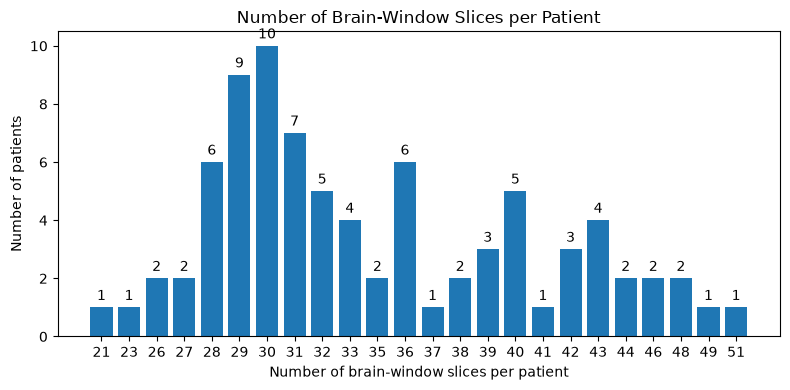

In [5]:
import matplotlib.pyplot as plt

slice_distribution = slice_counts_df["NumSlices"].value_counts().sort_index()

plt.figure(figsize=(8, 4))

bars = plt.bar(
    slice_distribution.index.astype(str),
    slice_distribution.values,
    width=0.8,
)

plt.xlabel("Number of brain-window slices per patient")
plt.ylabel("Number of patients")
plt.title("Number of Brain-Window Slices per Patient")

plt.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

The number of brain-window slices varies across patients. This variation reflects differences in the number of axial slices available for each CT scan.

## 3.3 ICH vs. Non-ICH Distribution and Hemorrhage Subtypes

We first examine the distribution of **ICH** and **Non-ICH** slices.

The binary `ICH` label is derived from the `No_Hemorrhage` field, where `1` indicates the presence of intracranial hemorrhage and `0` indicates no hemorrhage.

We then examine the distribution of the five annotated hemorrhage types.

In [6]:
diagnosis_df["ICH"] = 1 - diagnosis_df["No_Hemorrhage"]

label_counts = diagnosis_df["ICH"].value_counts().rename(index={0: "Non-ICH", 1: "ICH"})

label_percentages = (
    diagnosis_df["ICH"]
    .value_counts(normalize=True)
    .rename(index={0: "Non-ICH", 1: "ICH"})
    * 100
)

distribution_df = pd.DataFrame(
    {
        "Count": label_counts,
        "Percentage": label_percentages.round(2),
    }
)

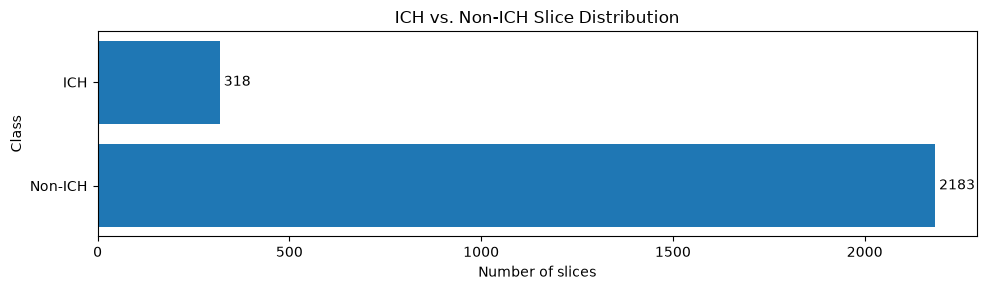

In [7]:
plt.figure(figsize=(10, 3))

bars = plt.barh(
    distribution_df.index,
    distribution_df["Count"],
)

plt.xlabel("Number of slices")
plt.ylabel("Class")
plt.title("ICH vs. Non-ICH Slice Distribution")

plt.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

In [8]:
hemorrhage_types = [
    "Intraventricular",
    "Intraparenchymal",
    "Subarachnoid",
    "Epidural",
    "Subdural",
]

hemorrhage_type_counts = (
    diagnosis_df[hemorrhage_types].sum().sort_values(ascending=False).rename("Count")
)

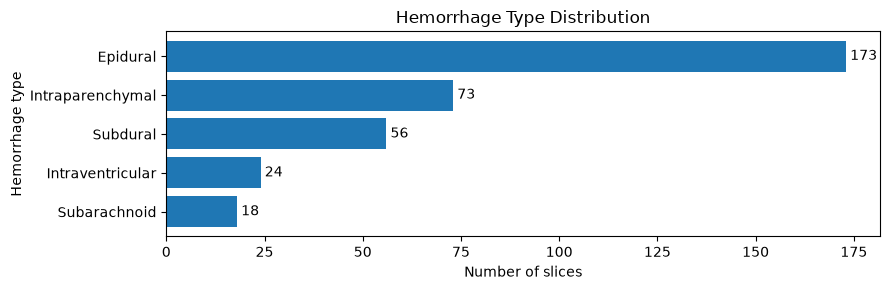

In [9]:
plt.figure(figsize=(9, 3))

bars = plt.barh(
    hemorrhage_type_counts.index,
    hemorrhage_type_counts.values,
)

plt.xlabel("Number of slices")
plt.ylabel("Hemorrhage type")
plt.title("Hemorrhage Type Distribution")

plt.bar_label(bars, padding=3)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 3.4 Representative Slice Visualization

We visualize representative brain-window CT slices to inspect their appearance and corresponding metadata.

First, we examine one specific slice together with its slice-level metadata. We then visualize representative **ICH** and **Non-ICH** examples to provide a qualitative view of the two classes.

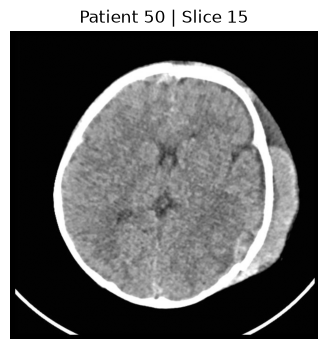

Slice metadata:


PatientNumber       50
SliceNumber         15
Intraventricular     0
Intraparenchymal     1
Subarachnoid         0
Epidural             0
Subdural             0
No_Hemorrhage        0
Fracture_Yes_No      1
ICH                  1
Name: 47, dtype: int64

In [10]:
from src.data_exploration import get_slice_metadata
from src.data_loading import load_ct_image

patient_id = 50
slice_number = 15

image = load_ct_image(
    DATA_DIR,
    patient_id=patient_id,
    slice_number=slice_number,
    window="brain",
)

slice_info = get_slice_metadata(
    diagnosis_df,
    patient_id=patient_id,
    slice_number=slice_number,
)

plt.figure(figsize=(4, 4))

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title(f"Patient {patient_id} | Slice {slice_number}")

plt.show()

print("Slice metadata:")
display(slice_info)

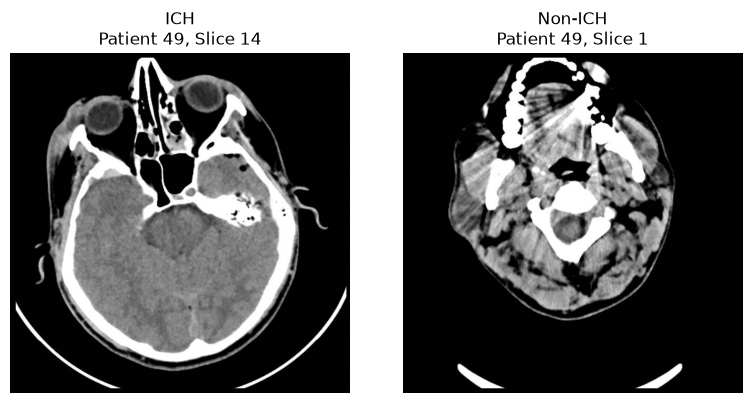

In [36]:
from src.data_exploration import get_example_slices

examples = get_example_slices(diagnosis_df)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, (label, metadata) in zip(axes, examples.items()):
    image = load_ct_image(
        DATA_DIR,
        patient_id=int(metadata["PatientNumber"]),
        slice_number=int(metadata["SliceNumber"]),
        window="brain",
    )

    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"{label}\n"
        f"Patient {int(metadata['PatientNumber'])}, "
        f"Slice {int(metadata['SliceNumber'])}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

# 4. Modeling Approach

The modeling approach is designed for the small number of independent patients and the goal of reliable ICH classification with subsequent uncertainty and explainability analysis.

## 4.1 Classifier Architecture & Rationale

I use an **ImageNet-pretrained ResNet-18** for binary **ICH vs. Non-ICH** classification.

The choice is motivated by:

* **Limited data:** With only **82 patients**, transfer learning is preferred over training from scratch.
* **Model complexity:** ResNet-18 provides sufficient capacity while keeping training computationally manageable.
* **Project focus:** The goal is to obtain a suitable and reproducible classifier for reliability and explainability analysis rather than benchmark multiple architectures.

## 4.2 Patient-Level Train/Validation/Test Split Strategy

Because multiple slices belong to each patient, the **patient** is used as the unit of splitting.

Patients are first divided into a **development set** and a held-out **test set**. The development set is then evaluated using **3-fold cross-validation**.

This prevents slices from the same patient from appearing across different splits and keeps the test set separate from model development.

## 4.3 Preprocessing & Augmentation

The preprocessing pipeline is designed for the ImageNet-pretrained ResNet-18.

* **Resize:** Images are resized to **224 × 224**, matching the model's input size.
* **Channels:** Grayscale CT images are replicated across three channels so the ImageNet-pretrained weights can be used without modifying the input layer.
* **Normalization:** Images are normalized using the **ImageNet mean and standard deviation**.
* **Augmentation:** Training images receive mild horizontal flips, small rotations, and small translations to improve robustness to minor variations.

Augmentation is applied **only to the training data**. Validation and test images use resizing and normalization without augmentation.

## 4.4 Training Configuration

The classifier is **fully fine-tuned** from ImageNet-pretrained weights in a single training stage.

During initial cross-validation, confusion matrices showed that the minority class was not being classified reliably with standard cross-entropy. I therefore use **weighted cross-entropy**, with class weights computed from the training labels of each fold.

The main training choices are:

| Component      | Choice                 | Purpose                                                     |
| -------------- | ---------------------- | ----------------------------------------------------------- |
| Optimizer      | **AdamW**              | Adaptive updates with decoupled weight decay                |
| Learning rate  | $1\times10^{-4}$       | Small updates suitable for fine-tuning pretrained weights   |
| Weight decay   | Selected by CV         | Regularization to reduce overfitting                        |
| LR scheduler   | **ReduceLROnPlateau**  | Reduces the learning rate when validation loss plateaus     |
| Early stopping | **Validation loss**    | Stops training when validation loss stops improving         |
| Patience       | **5 epochs**           | Allows temporary fluctuations before stopping               |
| Maximum epochs | **10**                 | Provides enough training time                               |



**Evaluation Metrics** : The main evaluation metrics are **F1-score, AUROC, sensitivity, and specificity**.
* **F1-score** is the main metric because the classes are imbalanced and it balances precision and recall.
* **AUROC** measures the model's ability to distinguish ICH from Non-ICH across classification thresholds.
* **Sensitivity** is important because missing an ICH case is particularly undesirable in this medical classification task.
* **Specificity** is reported to measure the model's ability to correctly identify Non-ICH cases.
* **Validation loss** is used to monitor training dynamics and overfitting and to guide learning-rate scheduling and early stopping.

These choices define the training and validation procedure used throughout the cross-validation experiment.



# 5. Cross-Validation Training

The development set is evaluated using **4-fold stratified cross-validation at the patient level**. A separate ResNet-18 is trained from the ImageNet-pretrained weights for each fold.

## 5.1 Full 4-Fold Cross-Validation

For each fold, the model is trained on the training patients and evaluated on the corresponding validation patients.

The training configuration defined in Section 4.4 is used.

The cross-validation experiment will be repeated for each candidate **weight decay** value. The same four patient-level folds and training procedure are used for every candidate to ensure a consistent comparison. The weight decay providing the most suitable cross-validation performance will be selected for subsequent final training.

The held-out test patients remain completely separate from cross-validation and are reserved for the final evaluation.


In [11]:
import json
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, WeightedRandomSampler

from src.dataset import CTICHImageDataset
from src.models import create_resnet18
from src.preprocessing import (
    compute_class_weights,
    create_patient_labels,
    create_stratified_folds,
    get_eval_transforms,
    get_train_transforms,
)
from src.training import train_model

In [ ]:
# Training configuration
BATCH_SIZE = 32
NUM_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 5

LEARNING_RATE = 1e-4

SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 2

NUM_WORKERS = 4

WEIGHT_DECAY_VALUES = [
    1e-4,
    1e-3,
    1e-2,
]

# Patient-level split
patient_labels = create_patient_labels(diagnosis_df)

split_path = Path("data/static_patient_split.json")

with open(split_path, "r") as f:
    split = json.load(f)

development_patients = patient_labels.loc[
    patient_labels["PatientNumber"].isin(split["development"])
]

test_patients = patient_labels.loc[patient_labels["PatientNumber"].isin(split["test"])]

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = device.type == "cuda"

In [ ]:
# Train one model for every weight-decay value on each CV fold,
# while keeping all other training settings unchanged.

cv_folds = create_stratified_folds(development_patients, n_splits=4)

# Store results separately for each weight-decay value and fold
fold_results = {}

for weight_decay in WEIGHT_DECAY_VALUES:

    print(f"\n{'#' * 60}")
    print(f"Weight decay: {weight_decay}")
    print(f"{'#' * 60}")

    fold_results[weight_decay] = {}

    # Train a separate model on each fold
    for fold in cv_folds:
        fold_number = fold["fold"]

        print(f"\n{'=' * 20} Fold {fold_number} {'=' * 20}")

        train_patient_ids = fold["train"]["PatientNumber"].tolist()
        validation_patient_ids = fold["validation"]["PatientNumber"].tolist()

        train_dataset = CTICHImageDataset(
            diagnosis_df=diagnosis_df,
            data_dir=DATA_DIR,
            patient_ids=train_patient_ids,
            transform=get_train_transforms(),
        )

        validation_dataset = CTICHImageDataset(
            diagnosis_df=diagnosis_df,
            data_dir=DATA_DIR,
            patient_ids=validation_patient_ids,
            transform=get_eval_transforms(),
        )
        train_labels = train_dataset.samples["ICH"].to_numpy()
        class_sample_counts = np.bincount(train_labels)
        sample_weights = np.array(
            [1.0 / class_sample_counts[label] for label in train_labels]
        )
        sampler = WeightedRandomSampler(
            weights=torch.as_tensor(sample_weights, dtype=torch.double),
            num_samples=len(train_dataset),
            replacement=True,
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            sampler=sampler,
            num_workers=NUM_WORKERS,
            pin_memory=pin_memory,
        )

        validation_loader = DataLoader(
            validation_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=pin_memory,
        )

        model = create_resnet18(num_classes=2).to(device)

        train_labels = fold["train"]["ICH"].values

        class_weights = compute_class_weights(train_labels).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        optimizer = AdamW(
            model.parameters(),
            lr=LEARNING_RATE,
            weight_decay=weight_decay,
        )

        scheduler = ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=SCHEDULER_FACTOR,
            patience=SCHEDULER_PATIENCE,
        )

        (
            model,
            history,
            best_validation_predictions,
            epoch_states,
            best_epoch,
        ) = train_model(
            model=model,
            train_loader=train_loader,
            validation_loader=validation_loader,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler,
            device=device,
            num_epochs=NUM_EPOCHS,
            patience=EARLY_STOPPING_PATIENCE,
            checkpoint_metric="f1",
        )

        fold_results[weight_decay][fold_number] = {
            "model": model,
            "history": history,
            "best_validation_predictions": best_validation_predictions,
            "epoch_states": epoch_states,
            "best_epoch": best_epoch,
            "train_patient_ids": train_patient_ids,
            "validation_patient_ids": validation_patient_ids,
        }

print("\nFull cross-validation training completed.")


############################################################
Weight decay: 0.0001
############################################################

==================== Fold 1 ====================
Epoch 01/10 | Train Loss: 0.3573 | Train F1: 0.8469 | Val Loss: 0.4555 | Val F1: 0.1935 | Val Sensitivity: 0.1406 | Val Specificity: 0.9551 | Val AUROC: 0.7199 | LR: 1.00e-04
Epoch 02/10 | Train Loss: 0.2036 | Train F1: 0.9183 | Val Loss: 0.6268 | Val F1: 0.1463 | Val Sensitivity: 0.0938 | Val Specificity: 0.9730 | Val AUROC: 0.7298 | LR: 1.00e-04
Epoch 03/10 | Train Loss: 0.1217 | Train F1: 0.9535 | Val Loss: 0.5041 | Val F1: 0.3359 | Val Sensitivity: 0.3438 | Val Specificity: 0.8989 | Val AUROC: 0.7791 | LR: 1.00e-04
Epoch 04/10 | Train Loss: 0.1277 | Train F1: 0.9527 | Val Loss: 0.5676 | Val F1: 0.3333 | Val Sensitivity: 0.2969 | Val Specificity: 0.9303 | Val AUROC: 0.7541 | LR: 5.00e-05
Epoch 05/10 | Train Loss: 0.0990 | Train F1: 0.9682 | Val Loss: 0.5791 | Val F1: 0.3741 | Val Sensitivity:

## 5.2 Cross-Validation Observations

The results show noticeable variation in validation performance across folds and weight-decay values. Training F1 also becomes substantially higher than validation F1 in later epochs, indicating a persistent train-validation gap.

The weight-decay values will therefore be compared using **aggregated out-of-fold (OOF) predictions** across all development patients.

In [ ]:
# Compute aggregated out-of-fold (OOF) metrics
# from the best validation epoch of each CV fold,
# separately for each weight-decay value.

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

threshold = 0.5

oof_results = {}

for weight_decay, weight_decay_results in fold_results.items():

    oof_labels = []
    oof_probabilities = []

    for fold_number, fold_result in weight_decay_results.items():

        validation_outputs = fold_result["best_validation_predictions"]

        oof_labels.extend(validation_outputs["labels"])
        oof_probabilities.extend(validation_outputs["probabilities"])

    oof_labels = np.asarray(oof_labels)
    oof_probabilities = np.asarray(oof_probabilities)

    # Sanity checks
    assert len(oof_labels) == len(oof_probabilities)
    assert len(oof_labels) > 0
    assert np.all((oof_probabilities >= 0) & (oof_probabilities <= 1))

    # Convert probabilities to predictions at the fixed threshold
    oof_predictions = (oof_probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        oof_labels,
        oof_predictions,
    ).ravel()

    metrics = {
        "Accuracy": accuracy_score(
            oof_labels,
            oof_predictions,
        ),
        "F1": f1_score(
            oof_labels,
            oof_predictions,
        ),
        "Sensitivity": tp / (tp + fn),
        "Specificity": tn / (tn + fp),
        "AUROC": roc_auc_score(
            oof_labels,
            oof_probabilities,
        ),
    }

    oof_results[weight_decay] = {
        "metrics": metrics,
        "confusion_matrix": {
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
        },
        "labels": oof_labels,
        "probabilities": oof_probabilities,
        "predictions": oof_predictions,
    }

import pandas as pd

oof_comparison = pd.DataFrame(
    {
        f"{weight_decay:.0e}": oof_results[weight_decay]["metrics"]
        for weight_decay in oof_results
    }
).T

oof_comparison.index.name = "Weight Decay"

display(oof_comparison.round(4))

,Accuracy,F1,Sensitivity,Specificity,AUROC
Weight Decay,,,,,
1e-04,0.8795,0.5172,0.5000,0.9357,0.8499
1e-03,0.8850,0.5230,0.4883,0.9438,0.8540
1e-02,0.8805,0.5380,0.5391,0.9311,0.8709


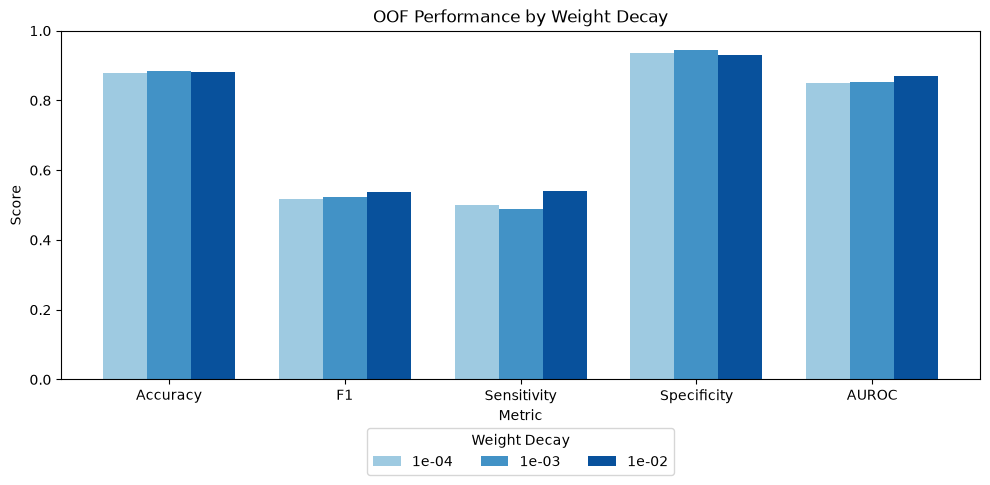

In [ ]:
# Extract OOF metrics
weight_decays = list(oof_results.keys())

metrics = [
    "Accuracy",
    "F1",
    "Sensitivity",
    "Specificity",
    "AUROC",
]

colors = [
    "#9ecae1",  # light blue — 1e-4
    "#4292c6",  # medium blue — 1e-3
    "#08519c",  # dark blue — 1e-2
]

# Plot
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, weight_decay in enumerate(weight_decays):
    values = [oof_results[weight_decay]["metrics"][metric] for metric in metrics]

    ax.bar(
        x + (i - 1) * width,
        values,
        width,
        label=f"{weight_decay:.0e}",
        color=colors[i],
    )

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("OOF Performance by Weight Decay")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)

ax.legend(
    title="Weight Decay",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
)

plt.tight_layout()
plt.show()

## 5.3 Weight Decay Selection and Cross-Validation Findings

Four-fold patient-level cross-validation compared three weight-decay values under the same strategy: **stochastic intensity augmentation, minority-class oversampling, and class-weighted cross-entropy**.

**Weight decay = 0.01** achieved the highest OOF **F1 (0.5380)**, **AUROC (0.8709)**, and **sensitivity (0.5391)**, while maintaining high specificity (0.9311). The combined training strategy also improved sensitivity compared with the baseline, suggesting that augmentation and oversampling helped reduce the tendency to favor the majority Non-ICH class. Their individual contributions cannot be isolated because they were evaluated together.

Based on the predefined F1 criterion, **weight decay = 0.01** is selected for final training.

## 5.4 Confidence Intervals

A **confidence interval (CI)** provides a range of plausible values around an estimated performance metric, reflecting uncertainty due to the finite evaluation sample.

CIs are therefore used to assess **how precise the reported performance estimates are**, rather than relying only on single metric values. For sensitivity and specificity, Wilson and Clopper-Pearson intervals are considered, while patient-level bootstrap intervals account for the dependence between slices from the same patient.


In [ ]:
# Compute Wilson, Clopper-Pearson, and patient-level bootstrap CIs
# for sensitivity and specificity on every validation fold.
import pandas as pd

from src.uncertainty import (
    clopper_pearson_ci,
    patient_level_bootstrap_ci,
    sensitivity_score,
    specificity_score,
    wilson_ci,
)

ci_results = []


for weight_decay, weight_decay_results in fold_results.items():

    for fold_number, result in weight_decay_results.items():

        validation_output = result["best_validation_predictions"]

        labels = np.asarray(validation_output["labels"])

        probabilities = np.asarray(validation_output["probabilities"])

        predictions = (probabilities >= 0.5).astype(int)

        validation_patient_ids = result["validation_patient_ids"]

        # Reconstruct one patient ID for each validation slice
        # in the same order used by CTICHImageDataset.
        validation_samples = diagnosis_df[
            diagnosis_df["PatientNumber"].isin(validation_patient_ids)
        ].reset_index(drop=True)

        patient_ids = validation_samples["PatientNumber"].to_numpy()

        tn, fp, fn, tp = confusion_matrix(
            labels,
            predictions,
            labels=[0, 1],
        ).ravel()

        # Sensitivity and specificity
        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)

        # Wilson CIs
        sensitivity_wilson = wilson_ci(
            successes=tp,
            total=tp + fn,
        )

        specificity_wilson = wilson_ci(
            successes=tn,
            total=tn + fp,
        )

        # Clopper-Pearson CIs
        sensitivity_cp = clopper_pearson_ci(
            successes=tp,
            total=tp + fn,
        )

        specificity_cp = clopper_pearson_ci(
            successes=tn,
            total=tn + fp,
        )

        # Patient-level bootstrap CIs
        sensitivity_bootstrap = patient_level_bootstrap_ci(
            labels=labels,
            predictions=predictions,
            patient_ids=patient_ids,
            metric=sensitivity_score,
        )

        specificity_bootstrap = patient_level_bootstrap_ci(
            labels=labels,
            predictions=predictions,
            patient_ids=patient_ids,
            metric=specificity_score,
        )

        ci_results.append(
            {
                "Weight Decay": weight_decay,
                "Fold": fold_number,
                "Sensitivity": sensitivity,
                "Sensitivity Wilson": sensitivity_wilson,
                "Sensitivity CP": sensitivity_cp,
                "Sensitivity Bootstrap": sensitivity_bootstrap,
                "Specificity": specificity,
                "Specificity Wilson": specificity_wilson,
                "Specificity CP": specificity_cp,
                "Specificity Bootstrap": specificity_bootstrap,
            }
        )


ci_results_df = pd.DataFrame(ci_results)

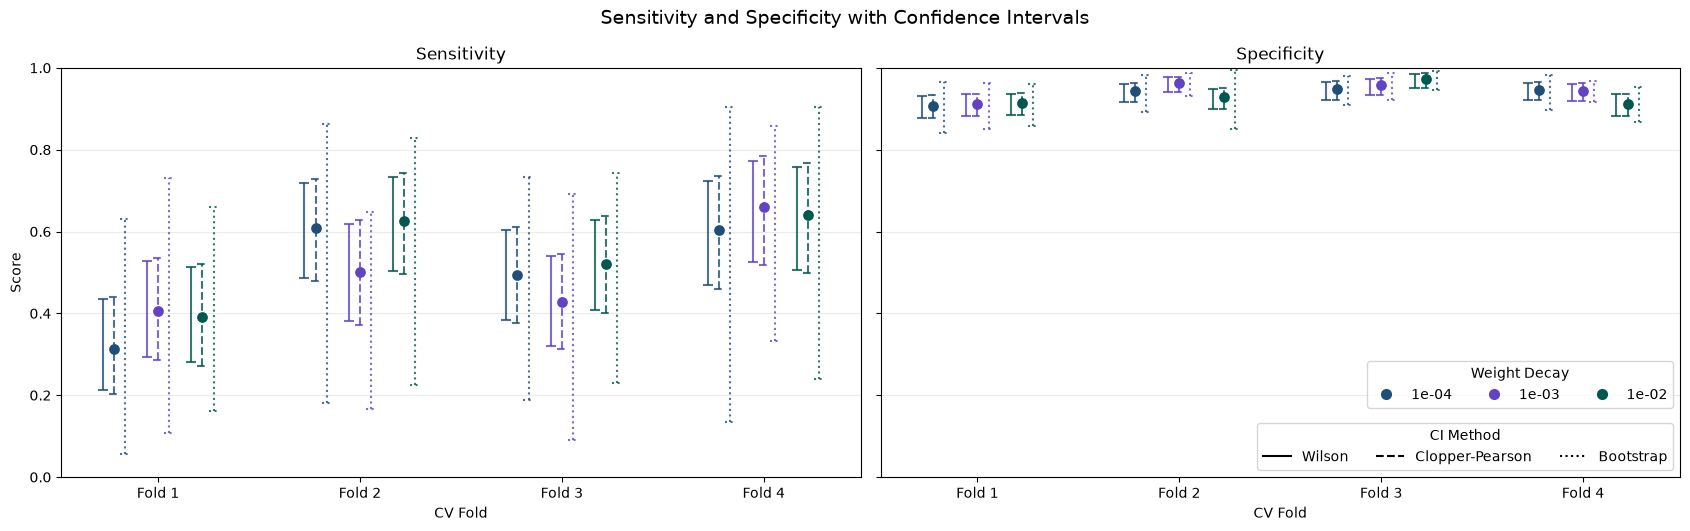

In [ ]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 6),
    sharey=True,
)

# Color = weight decay
colors = {
    1e-4: "#1F4E79",
    1e-3: "#6143C4",
    1e-2: "#00584F",
}

# Line style = CI method
ci_styles = {
    "Wilson": "-",
    "Clopper-Pearson": "--",
    "Bootstrap": ":",
}

ci_columns = {
    "Wilson": "Wilson",
    "Clopper-Pearson": "CP",
    "Bootstrap": "Bootstrap",
}

metrics = [
    "Sensitivity",
    "Specificity",
]

for ax, metric in zip(axes, metrics):
    for i, weight_decay in enumerate(sorted(ci_results_df["Weight Decay"].unique())):
        subset = ci_results_df[
            ci_results_df["Weight Decay"] == weight_decay
        ].sort_values("Fold")

        base_x = np.arange(len(subset))

        # Offset each weight decay
        point_x = base_x + (i - 1) * 0.22

        # Point estimate
        ax.scatter(
            point_x,
            subset[metric],
            color=colors[weight_decay],
            s=45,
            zorder=4,
        )

        # Confidence intervals
        for method, linestyle in ci_styles.items():
            ci_column = f"{metric} {ci_columns[method]}"

            lower = subset[ci_column].apply(lambda ci: ci[0]).to_numpy()

            upper = subset[ci_column].apply(lambda ci: ci[1]).to_numpy()

            # Offset CI methods slightly
            method_offset = {
                "Wilson": -0.055,
                "Clopper-Pearson": 0.0,
                "Bootstrap": 0.055,
            }[method]

            x = point_x + method_offset

            # Vertical CI
            ax.vlines(
                x,
                lower,
                upper,
                colors=colors[weight_decay],
                linestyles=linestyle,
                linewidth=1.5,
                alpha=0.8,
                zorder=2,
            )

            # CI caps
            cap_width = 0.025

            ax.hlines(
                lower,
                x - cap_width,
                x + cap_width,
                colors=colors[weight_decay],
                linestyles=linestyle,
                linewidth=1.5,
                alpha=0.8,
                zorder=2,
            )

            ax.hlines(
                upper,
                x - cap_width,
                x + cap_width,
                colors=colors[weight_decay],
                linestyles=linestyle,
                linewidth=1.5,
                alpha=0.8,
                zorder=2,
            )

    ax.set_title(metric)
    ax.set_xlabel("CV Fold")
    ax.set_xticks(np.arange(4))
    ax.set_xticklabels([f"Fold {i}" for i in range(1, 5)])
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.25)


axes[0].set_ylabel("Score")
# Weight decay legend
weight_decay_legend = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=colors[wd],
        markeredgecolor=colors[wd],
        markersize=7,
        label=f"{wd:.0e}",
    )
    for wd in sorted(colors)
]

# CI method legend
ci_legend = [
    Line2D(
        [0],
        [0],
        color="black",
        linestyle=style,
        linewidth=1.5,
        label=method,
    )
    for method, style in ci_styles.items()
]

# Weight decay legend
legend1 = axes[1].legend(
    handles=weight_decay_legend,
    title="Weight Decay",
    loc="best",
    bbox_to_anchor=(0.5, 0.0, 0.5, 0.3),
    ncol=3,
)

axes[1].add_artist(legend1)

# CI method legend
axes[1].legend(
    handles=ci_legend,
    title="CI Method",
    loc="lower right",
    ncol=3,
)

fig.suptitle(
    "Sensitivity and Specificity with Confidence Intervals",
    fontsize=14,
)

plt.tight_layout()

# Space for legends
plt.subplots_adjust(bottom=0.20)

plt.show()

* **Sensitivity varies considerably across folds**, ranging from 0.313 to 0.660 across the three weight-decay values, indicating variability in ICH detection across patient subsets.

* **Specificity is more stable and consistently high**, ranging from 0.908 to 0.973, indicating more consistent identification of Non-ICH cases.

* **Patient-level bootstrap CIs are generally wider** than Wilson and Clopper-Pearson CIs because they account for variability between patients and the dependence between slices from the same patient.

* **The wide bootstrap intervals indicate substantial uncertainty** around the sensitivity estimates, particularly given the limited number of patients.

* **The results support cautious interpretation of individual fold performance** rather than treating a single fold's sensitivity or specificity as a precise estimate of model performance.

* **Weight decay = 0.01 remains the selected value** based on the aggregated OOF results and the predefined F1 criterion. The confidence intervals are used to characterize uncertainty rather than to determine the selected hyperparameter.

# 6. Final Model & Test-Set Evaluation

After completing 4-fold cross-validation, we train the final classifier using all **65 development patients**.

The training configuration selected during cross-validation is retained for the final model. Since the final model uses the full development set, no validation split is used at this stage.

The **17 test patients remain completely unseen** during training and are used only for the final evaluation.

The final evaluation provides a single performance estimate on the held-out patient-level test set.

### 6.1 Final Model Training

The final classifier is trained once on the **full development set** using the configuration selected through 3-fold cross-validation.

Validation data is used during cross-validation for model and training decisions, including early stopping and checkpoint selection. Once these decisions are fixed, the final model is trained on **all development patients**, with a fixed number of epochs and no validation set or early stopping.

The held-out test set remains untouched until final evaluation.


In [ ]:
WEIGHT_DECAY = 0.01

development_patient_ids = development_patients["PatientNumber"].tolist()

train_dataset = CTICHImageDataset(
    diagnosis_df=diagnosis_df,
    data_dir=DATA_DIR,
    patient_ids=development_patient_ids,
    transform=get_train_transforms(),
)
sample_labels = train_dataset.samples["ICH"].to_numpy()
class_sample_counts = np.bincount(sample_labels)
sample_weights = np.array([1.0 / class_sample_counts[label] for label in sample_labels])
train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(train_dataset),
    replacement=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

model = create_resnet18(num_classes=2).to(device)

# Class weights from all development patients
train_labels = development_patients["ICH"].values

class_weights = compute_class_weights(train_labels).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Final training: no validation, no early stopping
model, history, _, epoch_states, final_epoch = train_model(
    model=model,
    train_loader=train_loader,
    validation_loader=None,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=None,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=None,
    checkpoint_metric=None,
)

print("\nFinal model training completed.")

Epoch 01/10 | Train Loss: 0.3852 | Train F1: 0.8316 | Train Sensitivity: 0.8770 | Train Specificity: 0.7600 | Train AUROC: 0.9007 | LR: 1.00e-04
Epoch 02/10 | Train Loss: 0.2268 | Train F1: 0.9156 | Train Sensitivity: 0.9550 | Train Specificity: 0.8728 | Train AUROC: 0.9668 | LR: 1.00e-04
Epoch 03/10 | Train Loss: 0.1645 | Train F1: 0.9355 | Train Sensitivity: 0.9442 | Train Specificity: 0.9291 | Train AUROC: 0.9823 | LR: 1.00e-04
Epoch 04/10 | Train Loss: 0.1499 | Train F1: 0.9452 | Train Sensitivity: 0.9598 | Train Specificity: 0.9319 | Train AUROC: 0.9847 | LR: 1.00e-04
Epoch 05/10 | Train Loss: 0.1242 | Train F1: 0.9572 | Train Sensitivity: 0.9747 | Train Specificity: 0.9388 | Train AUROC: 0.9891 | LR: 1.00e-04
Epoch 06/10 | Train Loss: 0.1211 | Train F1: 0.9576 | Train Sensitivity: 0.9650 | Train Specificity: 0.9515 | Train AUROC: 0.9897 | LR: 1.00e-04
Epoch 07/10 | Train Loss: 0.0970 | Train F1: 0.9660 | Train Sensitivity: 0.9771 | Train Specificity: 0.9530 | Train AUROC: 0.9932 

## 6.2 Test-Set Evaluation

The final model is evaluated on the **17 held-out test patients**.

This evaluation provides the final estimate of model performance on previously unseen patients. The analysis includes standard classification metrics, a confusion matrix, and an ROC curve.

In [ ]:
from src.training import evaluate_model

SELECTED_THRESHOLD = 0.5

test_patient_ids = set(test_patients["PatientNumber"])

# Test dataset
test_dataset = CTICHImageDataset(
    diagnosis_df=diagnosis_df,
    data_dir=DATA_DIR,
    patient_ids=test_patient_ids,
    transform=get_eval_transforms(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

print(f"\nNumber of test slices: {len(test_dataset)}")

# Final test evaluation
model.eval()

test_results = evaluate_model(
    model=model,
    data_loader=test_loader,
    device=device,
    threshold=SELECTED_THRESHOLD,
)

print("\nTest results:")
for metric, value in test_results["metrics"].items():
    print(f"{metric}: {value:.4f}")


Number of test slices: 518

Test results:
accuracy: 0.8359
f1: 0.4720
sensitivity: 0.6129
specificity: 0.8662
auroc: 0.8438


The model achieves an **accuracy of 83.59%**, while the **sensitivity is 61.29%** and **specificity is 86.62%**. Compared with the previous configuration, sensitivity has increased substantially, indicating that the model detects a larger proportion of ICH cases, although this comes with a reduction in specificity.

The **F1-score of 47.20%** reflects the remaining difficulty in balancing ICH detection with false-positive predictions. The **AUROC of 84.38%** indicates that the model retains a reasonable ability to discriminate between ICH and Non-ICH cases across classification thresholds.


## 6.3 Test-Set Results

The model shows substantially higher specificity (**95.83%**) than sensitivity (**38.00%**). The confusion matrix shows that the model correctly identifies most Non-ICH slices, but misses a considerable proportion of ICH slices.

Overall, the results indicate that **ICH detection remains a major limitation of the current classifier**.

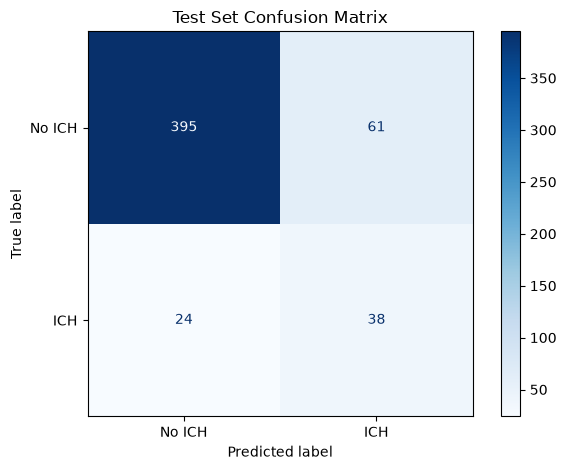

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, confusion_matrix

labels = test_results["labels"]
predictions = test_results["predictions"]

cm = confusion_matrix(labels, predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No ICH", "ICH"],
).plot(cmap="Blues")

plt.title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

**The confusion matrix:** shows that the model correctly classifies most Non-ICH slices (**395/456**), with **61 false positives**. For ICH, the model correctly detects **38/62 slices**, while **24 are missed**.

This corresponds to a **sensitivity of 61.29%** and a **specificity of 86.62%**. Compared with the previous configuration, the higher sensitivity indicates that the model detects a larger proportion of ICH cases, although this comes with more false-positive predictions and therefore lower specificity.

**The ROC curve:** evaluates the model's ability to distinguish **ICH from Non-ICH** across different classification thresholds.

It plots **sensitivity (true positive rate)** against the **false positive rate**. The **AUROC of 84.38%** summarizes the model's discriminative ability across thresholds, with higher values indicating better separation between the two classes.


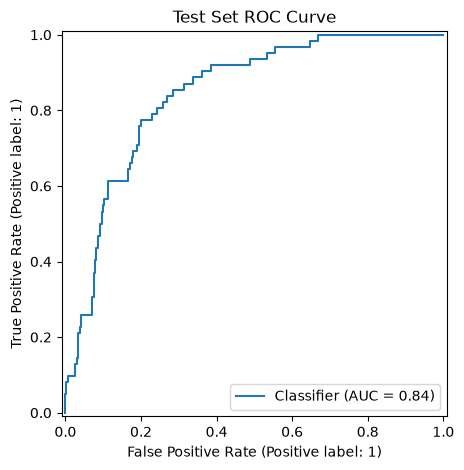

In [22]:
probabilities = test_results["probabilities"]
RocCurveDisplay.from_predictions(
    labels,
    probabilities,
)

plt.title("Test Set ROC Curve")
plt.tight_layout()
plt.show()

The ROC curve gives an **AUROC of 0.84**, showing that the model provides good discrimination between ICH and Non-ICH across different classification thresholds. The probability distribution is concentrated near 0 and 1, while around **20% of predictions fall between 0.25 and 0.75**, indicating a smaller group of less certain cases.

Overall, the model produces many confident predictions, but the probability distribution alone does not establish whether these confidence levels are well calibrated. The intermediate-probability cases are therefore of particular interest for the **reliability and uncertainty analysis** that follows.

# 7. Model Reliability

Good classification performance alone does not indicate whether a model's predictions can be trusted.

In a medical setting, it is also important to understand **how confident the model is in its predictions** and whether its confidence reflects its actual reliability.

This section examines two aspects of model reliability:

1. **Calibration:** whether predicted probabilities correspond to observed outcomes.
2. **Uncertainty:** whether incorrect or difficult predictions are associated with higher uncertainty.

### 7.1 Probability Calibration

The classifier outputs a probability of ICH for each CT slice. A well-calibrated model should produce probabilities that reflect the observed frequency of the corresponding outcomes.

For example, among predictions with an estimated probability of 0.8, approximately 80% should correspond to ICH cases.

We evaluate calibration using the **Brier score** and **Expected Calibration Error (ECE)**.

The Brier score measures how close the predicted probabilities are to the actual outcomes, while ECE measures the average gap between predicted confidence and observed accuracy across groups of predictions.

In [ ]:
import numpy as np
from sklearn.metrics import brier_score_loss

from src.uncertainty import expected_calibration_error

labels = np.asarray(test_results["labels"])
probabilities = np.asarray(test_results["probabilities"])

# Brier score
brier = brier_score_loss(labels, probabilities)
ece = expected_calibration_error(
    labels,
    probabilities,
)

print(f"Brier score: {brier:.4f}")
print(f"ECE: {ece:.4f}")

Brier score: 0.1363
ECE: 0.1043


The model obtains a **Brier score of 0.1363** and an **ECE of 0.1043**, indicating a noticeable difference between predicted confidence and observed outcomes. This suggests that the model's probabilities are **not perfectly calibrated**, particularly across confidence levels.

Therefore, although the model shows good discrimination (**AUROC = 0.84**), its predicted confidence should be interpreted with caution. A high-confidence prediction does not necessarily correspond to a correct prediction, motivating the following **uncertainty analysis**.

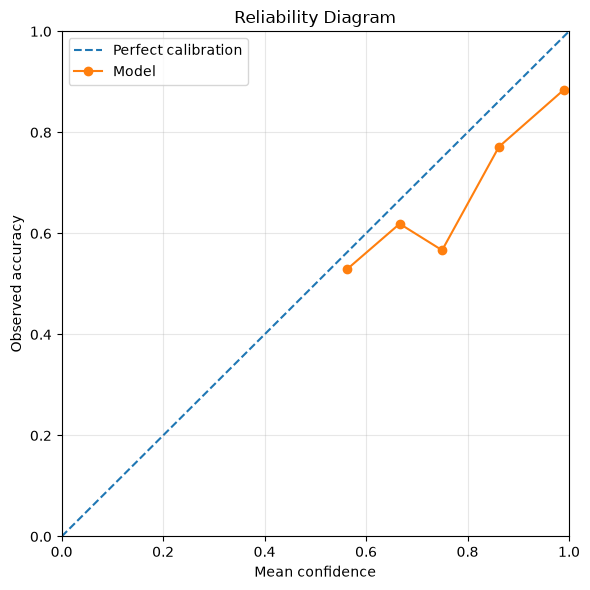

In [30]:
labels = np.asarray(test_results["labels"])
probabilities = np.asarray(test_results["probabilities"])

predictions = (probabilities >= 0.5).astype(int)

confidence = np.where(
    predictions == 1,
    probabilities,
    1 - probabilities,
)

correctness = (predictions == labels).astype(float)

n_bins = 10
bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

bin_confidences = []
bin_accuracies = []

for i in range(n_bins):
    lower = bin_edges[i]
    upper = bin_edges[i + 1]

    if i == 0:
        in_bin = (confidence >= lower) & (confidence <= upper)
    else:
        in_bin = (confidence > lower) & (confidence <= upper)

    if np.any(in_bin):
        bin_confidences.append(confidence[in_bin].mean())
        bin_accuracies.append(correctness[in_bin].mean())
    else:
        bin_confidences.append(np.nan)
        bin_accuracies.append(np.nan)

plt.figure(figsize=(6, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)

plt.plot(
    bin_confidences,
    bin_accuracies,
    marker="o",
    label="Model",
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xlabel("Mean confidence")
plt.ylabel("Observed accuracy")
plt.title("Reliability Diagram")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The reliability diagram shows that the model is **not perfectly calibrated**. Across the populated confidence bins, observed accuracy generally remains below the corresponding confidence, indicating **overconfidence**. For example, predictions with an average confidence of **0.990** have an observed accuracy of **0.884**, while the 0.8–0.9 bin has an average confidence of **0.862** and an accuracy of **0.771**.

Together with the **Brier score of 0.1363** and **ECE of 0.1043**, these results indicate a noticeable gap between the model's predicted confidence and its observed accuracy. The probabilities therefore provide useful information about prediction confidence, but they should **not be interpreted as directly calibrated probabilities**.

### 7.2 Uncertainty with MC Dropout

To explore predictive uncertainty, we use **Monte Carlo Dropout (MC Dropout)** during inference.

The model produces multiple predictions for the same image while dropout is enabled. The variation between these predictions provides an estimate of predictive uncertainty.

We then compare uncertainty between **correct and incorrect predictions** and examine individual cases where the model is uncertain or confidently wrong.

In [34]:
from src.uncertainty import collect_uncertainty_predictions

uncertainty_results = collect_uncertainty_predictions(
    model=model,
    data_loader=test_loader,
    device=device,
    n_samples=20,
)

print(f"Test slices: {len(uncertainty_results['labels'])}")
print(
    f"Mean uncertainty: "
    f"{torch.tensor(uncertainty_results['uncertainties']).mean():.4f}"
)

labels = np.asarray(uncertainty_results["labels"])
predictions = np.asarray(uncertainty_results["predictions"])
uncertainties = np.asarray(uncertainty_results["uncertainties"])

correct = predictions == labels
incorrect = ~correct

# Data
uncertainty_correct = uncertainties[correct]
uncertainty_incorrect = uncertainties[incorrect]

Test slices: 518
Mean uncertainty: 0.0241


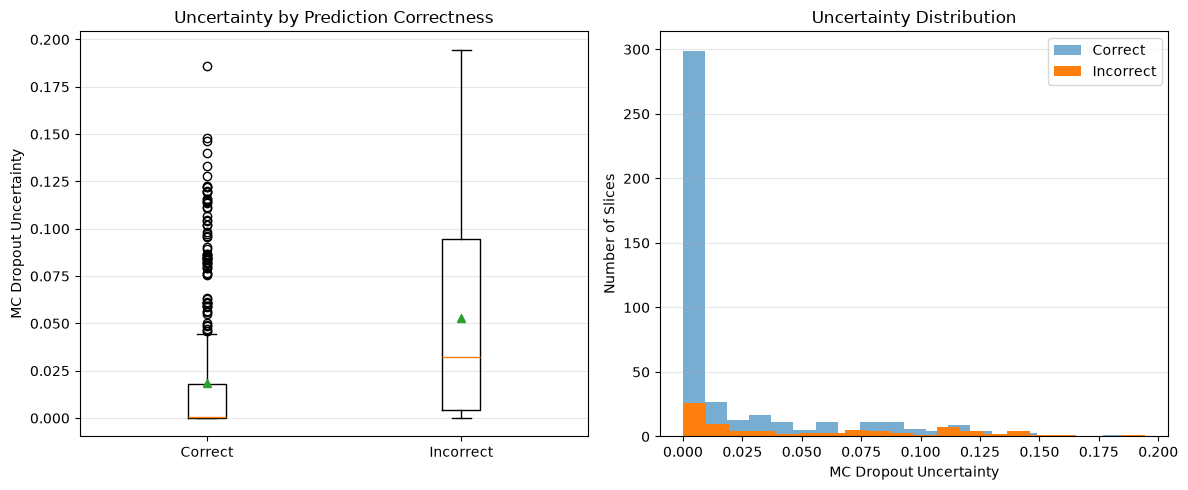

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
)

axes[0].boxplot(
    [uncertainty_correct, uncertainty_incorrect],
    tick_labels=["Correct", "Incorrect"],
    showmeans=True,
)

axes[0].set_title("Uncertainty by Prediction Correctness")
axes[0].set_ylabel("MC Dropout Uncertainty")
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(
    uncertainty_correct,
    bins=20,
    alpha=0.6,
    label="Correct",
)

axes[1].hist(
    uncertainty_incorrect,
    bins=20,
    label="Incorrect",
)

axes[1].set_title("Uncertainty Distribution")
axes[1].set_xlabel("MC Dropout Uncertainty")
axes[1].set_ylabel("Number of Slices")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The model has a mean MC Dropout uncertainty of **0.0241** across the 518 test slices.

Incorrect predictions generally show higher uncertainty than correct predictions, suggesting that MC Dropout captures some information about prediction difficulty. However, the uncertainty distributions overlap substantially, with some incorrect predictions still showing low uncertainty.

Therefore, **higher uncertainty is associated with a greater likelihood of an incorrect prediction, but it does not reliably identify all model errors**. This is particularly relevant in medical imaging, where confident incorrect predictions may remain difficult to detect.

In [ ]:
# Indices of the 5 most uncertain predictions
most_uncertain = np.argsort(uncertainties)[-5:][::-1]

print("\nMost uncertain predictions:")
for idx in most_uncertain:
    print(
        f"Index {idx}: "
        f"Actual={labels[idx]}, "
        f"Predicted={predictions[idx]}, "
        f"P(ICH)={uncertainty_results['probabilities'][idx]:.4f}, "
        f"Uncertainty={uncertainties[idx]:.4f}, "
        f"{'CORRECT' if correct[idx] else 'INCORRECT'}"
    )

incorrect_indices = np.where(incorrect)[0]
confidently_wrong = incorrect_indices[np.argsort(uncertainties[incorrect_indices])][:5]

print("\nMost confident incorrect predictions:")
for idx in confidently_wrong:
    print(
        f"Index {idx}: "
        f"Actual={labels[idx]}, "
        f"Predicted={predictions[idx]}, "
        f"P(ICH)={uncertainty_results['probabilities'][idx]:.4f}, "
        f"Uncertainty={uncertainties[idx]:.4f}"
    )


Most uncertain predictions:
Index 497: Actual=0, Predicted=1, P(ICH)=0.6552, Uncertainty=0.1946, INCORRECT
Index 220: Actual=0, Predicted=0, P(ICH)=0.4551, Uncertainty=0.1860, CORRECT
Index 298: Actual=0, Predicted=1, P(ICH)=0.5203, Uncertainty=0.1569, INCORRECT
Index 143: Actual=0, Predicted=0, P(ICH)=0.3838, Uncertainty=0.1481, CORRECT
Index 299: Actual=0, Predicted=0, P(ICH)=0.4169, Uncertainty=0.1465, CORRECT

Most confident incorrect predictions:
Index 329: Actual=0, Predicted=1, P(ICH)=1.0000, Uncertainty=0.0000
Index 168: Actual=1, Predicted=0, P(ICH)=0.0000, Uncertainty=0.0000
Index 167: Actual=1, Predicted=0, P(ICH)=0.0000, Uncertainty=0.0000
Index 330: Actual=0, Predicted=1, P(ICH)=0.9999, Uncertainty=0.0000
Index 504: Actual=0, Predicted=1, P(ICH)=0.9999, Uncertainty=0.0001


### 7.3 Reliability Analysis

* **Uncertainty:** Incorrect predictions have higher average uncertainty than correct predictions (**0.0514 vs. 0.0190**).
* **What this means:** The model is generally less certain when making incorrect predictions, suggesting that MC Dropout captures some information about prediction difficulty.
* **Important limitation:** The uncertainty distributions still overlap substantially, and some incorrect predictions remain associated with low uncertainty.
* **Overall:** Uncertainty can identify some difficult cases, but it **cannot reliably detect all model errors**.

The calibration analysis also indicates that the model is **overconfident**, with predicted confidence generally higher than observed accuracy. To improve the reliability of its predicted probabilities, we apply **temperature scaling** as a post-hoc calibration method.

## 7.4 Temperature Scaling

The calibration analysis showed that the model's predicted probabilities were somewhat overconfident. We therefore apply **temperature scaling**, a post-hoc calibration method that adjusts the model's logits without retraining the classifier.

The temperature is learned from the **out-of-fold (OOF) predictions** generated during 3-fold cross-validation. The learned temperature is then applied to the final model's test logits to obtain calibrated probabilities.


In [ ]:
from src.uncertainty import fit_temperature

# Collect out-of-fold validation logits and labels
oof_logits = []
oof_labels = []
best_fold_results = fold_results[WEIGHT_DECAY]
for fold_number, results in best_fold_results.items():

    validation_predictions = results["best_validation_predictions"]

    oof_logits.extend(validation_predictions["logits"])
    oof_labels.extend(validation_predictions["labels"])

oof_logits = torch.tensor(
    np.asarray(oof_logits),
    dtype=torch.float32,
)

oof_labels = torch.tensor(
    oof_labels,
    dtype=torch.long,
)

print(f"OOF samples: {len(oof_labels)}")

# Fit temperature using OOF validation predictions
temperature = fit_temperature(
    oof_logits,
    oof_labels,
)

print(f"Learned temperature: {temperature:.4f}")

# Apply temperature scaling
scaled_oof_logits = oof_logits / temperature

calibrated_oof_probabilities = torch.softmax(
    scaled_oof_logits,
    dim=1,
)[:, 1]

calibrated_oof_probabilities = calibrated_oof_probabilities.cpu().numpy()

OOF samples: 1983
Learned temperature: 1.1456


In [49]:
model.eval()

all_logits = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        all_logits.append(outputs.cpu())
        all_labels.append(labels.cpu())

test_logits = torch.cat(all_logits).numpy()
test_labels = torch.cat(all_labels).numpy()

test_probabilities = torch.softmax(
    torch.tensor(test_logits),
    dim=1,
)[:, 1].numpy()

test_predictions = (test_probabilities >= 0.5).astype(int)

test_results = {
    "labels": test_labels,
    "predictions": test_predictions,
    "probabilities": test_probabilities,
    "logits": test_logits,
}

In [ ]:
test_logits = torch.tensor(
    test_results["logits"],
    dtype=torch.float32,
)

scaled_test_logits = test_logits / temperature

calibrated_test_probabilities = torch.softmax(
    scaled_test_logits,
    dim=1,
)[:, 1].numpy()

calibrated_test_predictions = (calibrated_test_probabilities >= 0.5).astype(int)

In [ ]:
import numpy as np
from sklearn.metrics import brier_score_loss

from src.uncertainty import expected_calibration_error

test_labels = np.asarray(test_results["labels"])
test_probabilities = np.asarray(test_results["probabilities"])

test_logits = torch.tensor(
    test_results["logits"],
    dtype=torch.float32,
)

calibrated_test_probabilities = (
    torch.softmax(
        test_logits / temperature,
        dim=1,
    )[:, 1]
    .cpu()
    .numpy()
)

brier_test_before = brier_score_loss(
    test_labels,
    test_probabilities,
)

ece_test_before = expected_calibration_error(
    test_labels,
    test_probabilities,
)

brier_test_after = brier_score_loss(
    test_labels,
    calibrated_test_probabilities,
)

ece_test_after = expected_calibration_error(
    test_labels,
    calibrated_test_probabilities,
)

print("Test Set - Before Temperature Scaling:")
print(f"Brier score: {brier_test_before:.4f}")
print(f"ECE:         {ece_test_before:.4f}")

print("\nTest Set - After Temperature Scaling:")
print(f"Temperature: {temperature:.4f}")
print(f"Brier score: {brier_test_after:.4f}")
print(f"ECE:         {ece_test_after:.4f}")

Test Set - Before Temperature Scaling:
Brier score: 0.1196
ECE:         0.1038

Test Set - After Temperature Scaling:
Temperature: 1.1456
Brier score: 0.1170
ECE:         0.0966


Temperature scaling **slightly improved the Brier score** and **reduced the ECE** on the held-out test set, indicating a modest improvement in calibration.

### 7.5 Reliability After Temperature Scaling

The Brier score and ECE showed a **modest improvement** after temperature scaling. The reliability diagram below compares the model's calibration **before and after scaling** to visualize this change.

The diagonal represents **perfect calibration**, where predicted confidence matches the observed accuracy. A calibrated model should therefore have points closer to this diagonal.


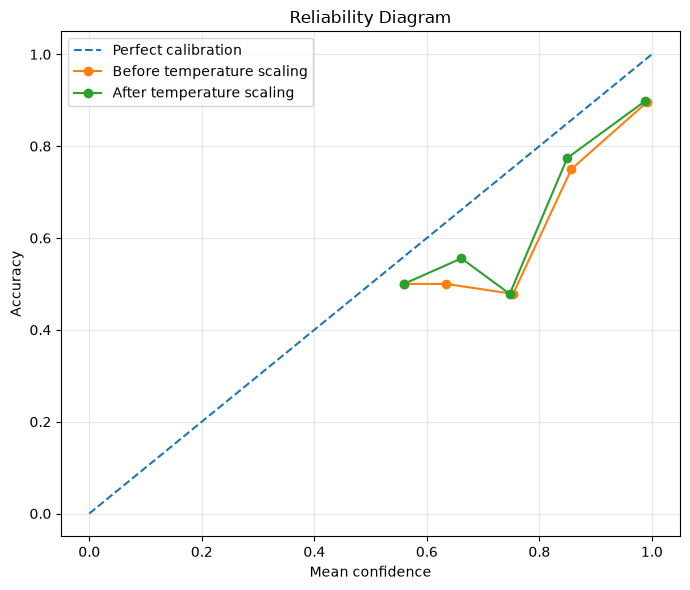

In [ ]:
test_labels = np.asarray(test_results["labels"])
test_probabilities = np.asarray(test_results["probabilities"])

test_logits = torch.tensor(
    test_results["logits"],
    dtype=torch.float32,
)

calibrated_test_probabilities = (
    torch.softmax(
        test_logits / temperature,
        dim=1,
    )[:, 1]
    .cpu()
    .numpy()
)


# Convert probabilities to confidence
def get_reliability_bins(labels, probabilities, n_bins=10):

    predictions = (probabilities >= 0.5).astype(int)

    confidence = np.where(
        predictions == 1,
        probabilities,
        1 - probabilities,
    )

    correctness = (predictions == labels).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1,
    )

    bin_confidences = []
    bin_accuracies = []

    for i in range(n_bins):
        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == 0:
            in_bin = (confidence >= lower) & (confidence <= upper)
        else:
            in_bin = (confidence > lower) & (confidence <= upper)

        if np.any(in_bin):
            bin_confidences.append(confidence[in_bin].mean())
            bin_accuracies.append(correctness[in_bin].mean())
        else:
            bin_confidences.append(np.nan)
            bin_accuracies.append(np.nan)

    return (
        np.asarray(bin_confidences),
        np.asarray(bin_accuracies),
    )


# Before calibration
confidence_before, accuracy_before = get_reliability_bins(
    test_labels,
    test_probabilities,
)

# After calibration
confidence_after, accuracy_after = get_reliability_bins(
    test_labels,
    calibrated_test_probabilities,
)


# Reliability diagram
plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)

plt.plot(
    confidence_before,
    accuracy_before,
    marker="o",
    label="Before temperature scaling",
)

plt.plot(
    confidence_after,
    accuracy_after,
    marker="o",
    label="After temperature scaling",
)

plt.xlabel("Mean confidence")
plt.ylabel("Accuracy")
plt.title("Reliability Diagram")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


The reliability diagram shows that temperature scaling **slightly improves calibration**, but the model remains somewhat overconfident. After scaling, observed accuracy is still below mean confidence across the populated bins.

This is consistent with the decrease in **Brier score (0.1196 → 0.1170)** and **ECE (0.1038 → 0.0966)**. Therefore, temperature scaling reduces the calibration error but does not fully eliminate the gap between predicted confidence and observed accuracy.

# 8. Error Analysis & Explainability

The test-set results show that the classifier makes both **false positive and false negative errors**. This section examines selected misclassifications in more detail to better understand the model's behavior.

We combine **uncertainty analysis** with **Grad-CAM visualizations** to investigate both how confident the model is and which image regions contribute to its predictions.

### 8.1 Selecting Representative Errors

Rather than analyzing all misclassified slices, two representative errors are selected for detailed analysis:

* **One false negative:** an ICH slice incorrectly classified as Non-ICH.
* **One false positive:** a Non-ICH slice incorrectly classified as ICH.

To make the selection explicit, we choose the **most confident error** from each category. This allows us to examine cases where the model is strongly confident despite making an incorrect prediction.

These two cases are then analyzed using **MC Dropout uncertainty** and **Grad-CAM** to investigate the model's confidence and visual evidence.


In [57]:
labels = np.asarray(test_results["labels"])
predictions = np.asarray(test_results["predictions"])
probabilities = np.asarray(test_results["probabilities"])

misclassified_indices = np.where(labels != predictions)[0]

# Separate error types
false_negative_indices = misclassified_indices[
    (labels[misclassified_indices] == 1) & (predictions[misclassified_indices] == 0)
]

false_positive_indices = misclassified_indices[
    (labels[misclassified_indices] == 0) & (predictions[misclassified_indices] == 1)
]

# Select the most confident error from each category
fn_idx = false_negative_indices[np.argmax(1 - probabilities[false_negative_indices])]

fp_idx = false_positive_indices[np.argmax(probabilities[false_positive_indices])]

selected_indices = [fn_idx, fp_idx]

selected_errors = test_dataset.samples.iloc[selected_indices].copy()

selected_errors["Prediction"] = predictions[selected_indices]
selected_errors["Probability_ICH"] = probabilities[selected_indices]

selected_errors["Error"] = [
    "False Negative",
    "False Positive",
]

selected_errors = selected_errors[
    [
        "PatientNumber",
        "SliceNumber",
        "ICH",
        "Prediction",
        "Probability_ICH",
        "Error",
    ]
].reset_index(drop=True)

print("Selected representative errors:")
display(selected_errors)

Selected representative errors:


,PatientNumber,SliceNumber,ICH,Prediction,Probability_ICH,Error
0,75,30,1,0,0.000562,False Negative
1,129,17,0,1,0.992769,False Positive


In [58]:
selected_errors = [
    {
        "patient": int(row["PatientNumber"]),
        "slice": int(row["SliceNumber"]),
        "actual_label": int(row["ICH"]),
    }
    for _, row in selected_errors.iterrows()
]
selected_samples = []

for item in selected_errors:
    sample = test_dataset.samples[
        (test_dataset.samples["PatientNumber"] == item["patient"])
        & (test_dataset.samples["SliceNumber"] == item["slice"])
    ].iloc[0]

    selected_samples.append(sample)

In [60]:
from src.uncertainty import mc_dropout_predict

images = []

for sample in selected_samples:
    image = load_ct_image(
        DATA_DIR,
        patient_id=int(sample["PatientNumber"]),
        slice_number=int(sample["SliceNumber"]),
        window="brain",
    )

    image = get_eval_transforms()(image)
    images.append(image)

images = torch.stack(images)

mc_results = mc_dropout_predict(
    model=model,
    images=images,
    device=device,
    n_samples=20,
)

for i, sample in enumerate(selected_samples):
    print(
        f"Patient {int(sample['PatientNumber'])}, "
        f"Slice {int(sample['SliceNumber'])} | "
        f"Actual: {int(sample['ICH'])} | "
        f"Prediction: {int(mc_results['predictions'][i])} | "
        f"Probability: {mc_results['probabilities'][i].item():.6f} | "
        f"Uncertainty: {mc_results['uncertainty'][i].item():.4f}"
    )

model.eval();

Patient 75, Slice 30 | Actual: 1 | Prediction: 0 | Probability: 0.000702 | Uncertainty: 0.0004
Patient 129, Slice 17 | Actual: 0 | Prediction: 1 | Probability: 0.992315 | Uncertainty: 0.0038


### 8.2 MC Dropout Analysis of Representative Errors

* **Patient 75, slice 30:** false negative, with P(ICH) = **0.0007** and uncertainty = **0.0004**. The model strongly predicts Non-ICH despite the presence of ICH.
* **Patient 129, slice 17:** false positive, with P(ICH) = **0.9923** and uncertainty = **0.0038**. The model strongly predicts ICH despite the absence of hemorrhage.

Both cases show **high-confidence incorrect predictions with low MC Dropout uncertainty**, indicating that the model's predictions remain relatively stable across stochastic forward passes.

MC Dropout therefore helps assess the **stability of the predictions**, while Grad-CAM is used next to investigate **which regions of the CT image contribute to the predictions**.

### 8.3 Grad-CAM Visualization

Grad-CAM is used to visualize the image regions that contribute most to the model's **ICH prediction**.

For the two selected errors, we compare the highlighted regions with the actual CT images to investigate whether the model focuses on **relevant intracranial regions** or relies on potentially misleading visual features.

The Grad-CAM target is set to the **ICH class (class 1)** for both cases, allowing us to examine the evidence associated with the ICH prediction even when the model ultimately predicts Non-ICH.


In [61]:
from src.explainability import GradCAM

model.eval()
grad_cam = GradCAM(
    model=model,
    target_layer=model.layer4[-1],
)

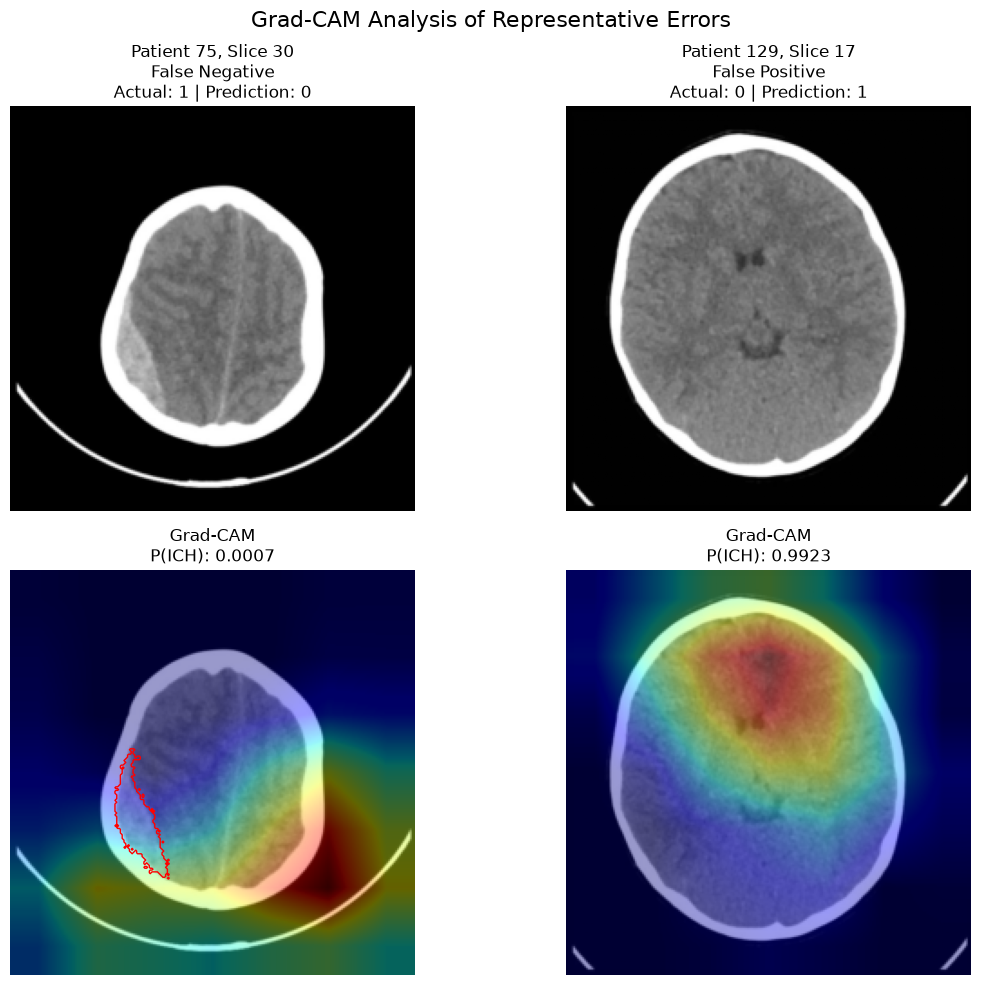

In [63]:
from pathlib import Path

import torch.nn.functional as F
from PIL import Image

fig, axes = plt.subplots(
    2,
    len(selected_samples),
    figsize=(6 * len(selected_samples), 10),
)

if len(selected_samples) == 1:
    axes = axes.reshape(2, 1)

mean = 0.485
std = 0.229

for i, sample in enumerate(selected_samples):
    patient_id = int(sample["PatientNumber"])
    slice_id = int(sample["SliceNumber"])
    actual = int(sample["ICH"])

    prediction = int(mc_results["predictions"][i])
    probability = mc_results["probabilities"][i].item()

    image = images[i].unsqueeze(0).to(device)

    cam, output = grad_cam.generate(
        image=image,
        target_class=prediction,
    )

    cam_resized = F.interpolate(
        cam,
        size=(224, 224),
        mode="bilinear",
        align_corners=False,
    )

    cam_resized = cam_resized.squeeze().detach().cpu().numpy()

    image_np = images[i][0].detach().cpu().numpy()
    image_np = image_np * std + mean
    image_np = image_np.clip(0, 1)

    axes[0, i].imshow(
        image_np,
        cmap="gray",
    )

    axes[0, i].axis("off")

    axes[1, i].imshow(
        image_np,
        cmap="gray",
    )

    axes[1, i].imshow(
        cam_resized,
        cmap="jet",
        alpha=0.4,
    )

    if actual == 1 and prediction == 0:
        patient_folder = f"{patient_id:03d}"

        mask_path = (
            Path(DATA_DIR)
            / "Patients_CT"
            / patient_folder
            / "brain"
            / f"{slice_id}_HGE_Seg.jpg"
        )

        if mask_path.exists():
            mask = Image.open(mask_path).convert("L")
            mask = np.array(mask)

            mask = Image.fromarray(mask).resize(
                (224, 224),
                Image.NEAREST,
            )

            mask = np.array(mask)
            mask_binary = mask > 0

            axes[1, i].contour(
                mask_binary,
                levels=[0.5],
                colors="red",
                linewidths=1,
            )

        else:
            print(f"Segmentation not found: {mask_path}")

    axes[1, i].axis("off")

    error_type = (
        "False Negative" if actual == 1 and prediction == 0 else "False Positive"
    )

    axes[0, i].set_title(
        f"Patient {patient_id}, Slice {slice_id}\n"
        f"{error_type}\n"
        f"Actual: {actual} | Prediction: {prediction}"
    )

    axes[1, i].set_title(f"Grad-CAM\nP(ICH): {probability:.4f}")

fig.suptitle(
    "Grad-CAM Analysis of Representative Errors",
    fontsize=16,
)

plt.tight_layout()
plt.show()


Grad-CAM reveals imperfect alignment between the model's highlighted regions and the expected hemorrhagic findings.

* **False negative (Patient 75, Slice 30):** The hemorrhage is clearly visible on the left side of the CT, close to the skull. However, Grad-CAM highlights a region on the right side, partially outside the brain and extending into the skull and dark background. This suggests that the model did not focus on the visible hemorrhagic region when making its prediction.

* **False positive (Patient 129, Slice 17):** No clear hemorrhage is visible in the CT. Grad-CAM instead highlights a darker region within the brain, suggesting that the model may be responding to an image pattern that resembles a feature associated with ICH, despite the absence of an apparent hemorrhage.

Overall, these cases suggest that the model's predictions are not always supported by spatially meaningful evidence. In particular, the false negative shows limited alignment with the visible hemorrhage, while the false positive suggests that non-hemorrhagic intensity patterns may contribute to an incorrect ICH prediction.

### 8.4 Future Explainability Improvements

The Grad-CAM analysis suggests that the model may sometimes rely on regions outside the relevant brain structures. A potential future improvement is to incorporate **brain-region masking** to reduce the influence of the skull and background during training and inference.

This could be evaluated as a separate experiment by comparing the original model with a brain-masked model under the same patient-level split and evaluation protocol. The effect could be assessed using both predictive performance and explainability measures, including the proportion of Grad-CAM activation located within the brain and, where annotations are available, within hemorrhagic regions.

Additionally, **occlusion or perturbation-based analysis** could be used to test whether highlighted regions actually influence the model's predictions.

# 9. Latent-Space Counterfactual Exploration

## 9.1 Motivation & Method

To further investigate the model's decision behavior, we explore **latent-space counterfactuals** using an autoencoder.

The CT image is encoded into a latent representation, shifted in a direction that changes the classifier's ICH score, and then decoded into a modified image.

**CT → Encoder → Latent shift → Decoder → Modified CT**

This is an exploratory method for studying how changes in the representation affect the model's prediction.

## 9.2 Autoencoder Architecture, Training, Reconstruction Quality

A convolutional autoencoder is trained to reconstruct the CT images from a compact latent representation.

The autoencoder is trained using the **development patients only**, with mean squared error (MSE) as the reconstruction loss.

After training, we compare original and reconstructed images to assess how well the autoencoder preserves the visual information needed for the subsequent latent-space analysis.


In [ ]:
from src.autoencoder import (
    CTICHAutoencoderDataset,
    get_autoencoder_transforms,
)

autoencoder_dataset = CTICHAutoencoderDataset(
    diagnosis_df=diagnosis_df,
    data_dir=DATA_DIR,
    patient_ids=sorted(development_patient_ids),
    transform=get_autoencoder_transforms(),
)

autoencoder_loader = DataLoader(
    autoencoder_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=False,
)

print(f"Number of images: {len(autoencoder_dataset)}")

In [ ]:
# Preview images using the autoencoder data pipeline
preview_images = next(iter(autoencoder_loader))

fig, axes = plt.subplots(
    1,
    4,
    figsize=(12, 3),
)

for i, ax in enumerate(axes):
    ax.imshow(
        preview_images[i, 0],
        cmap="gray",
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Initialize the autoencoder and verify its input, latent, and output shapes
from src.autoencoder import CTICHAutoencoder

autoencoder = CTICHAutoencoder(
    latent_dim=512,
).to(device)

preview_images = preview_images.to(device)

with torch.no_grad():
    latent = autoencoder.encode(preview_images)
    reconstruction = autoencoder(preview_images)

print("Input:", preview_images.shape)
print("Latent:", latent.shape)
print("Reconstruction:", reconstruction.shape)

num_parameters = sum(parameter.numel() for parameter in autoencoder.parameters())

print(f"Parameters: {num_parameters:,}")

In [ ]:
# Train the autoencoder and keep the best reconstruction model
import copy

criterion = nn.MSELoss()

optimizer = AdamW(
    autoencoder.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

num_epochs = 50

history = []
best_loss = float("inf")
best_state = None

for epoch in range(num_epochs):
    autoencoder.train()

    running_loss = 0.0

    for batch_images in autoencoder_loader:
        batch_images = batch_images.to(device)

        optimizer.zero_grad()

        reconstructions = autoencoder(batch_images)

        loss = criterion(
            reconstructions,
            batch_images,
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_images.size(0)

    epoch_loss = running_loss / len(autoencoder_loader)

    history.append(epoch_loss)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_state = copy.deepcopy(autoencoder.state_dict())

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} "
        f"- Reconstruction loss: {epoch_loss:.6f}"
    )

autoencoder.load_state_dict(best_state)

In [ ]:
# Plot the autoencoder reconstruction loss
plt.figure(figsize=(6, 4))

plt.plot(history)

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Autoencoder Training Loss")

plt.tight_layout()
plt.show()

In [ ]:
# Compare original CT images with their reconstructions
autoencoder.eval()

with torch.no_grad():
    reconstruction_images = next(iter(autoencoder_loader)).to(device)

    reconstructions = autoencoder(reconstruction_images)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 6),
)

for i in range(4):
    axes[0, i].imshow(
        reconstruction_images[i, 0].cpu(),
        cmap="gray",
    )
    axes[0, i].axis("off")
    axes[0, i].set_title("Original")

    axes[1, i].imshow(
        reconstructions[i, 0].cpu(),
        cmap="gray",
    )
    axes[1, i].axis("off")
    axes[1, i].set_title("Reconstruction")

plt.tight_layout()
plt.show()

## 9.3 Latent-Space Gradient Shift & Counterfactual Generation

We encode each selected CT image into the autoencoder's latent space and compute the gradient of the classifier's ICH score with respect to the latent representation.

The latent representation is then shifted in the direction that moves the prediction toward the correct class. The shifted representation is decoded to obtain a counterfactual image.

The original image, reconstruction, and counterfactual are compared using their predicted ICH probabilities.


In [ ]:
from src.autoencoder import prepare_for_classifier

alpha = 1.0

autoencoder.eval()
model.eval()

for example in selected_errors:
    patient_id = example["patient"]
    slice_number = example["slice"]
    actual_label = example["actual_label"]

    image_pil = load_ct_image(
        DATA_DIR,
        patient_id=patient_id,
        slice_number=slice_number,
        window="brain",
    )

    image_tensor = get_autoencoder_transforms()(image_pil)
    image = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        z_original = autoencoder.encode(image)
        reconstruction = autoencoder.decode(z_original).clamp(0, 1)

    with torch.no_grad():
        original_input = prepare_for_classifier(image)
        original_logits = model(original_input)

        original_p_ich = torch.softmax(
            original_logits,
            dim=1,
        )[0, 1].item()

        reconstruction_input = prepare_for_classifier(reconstruction)
        reconstruction_logits = model(reconstruction_input)

        reconstruction_p_ich = torch.softmax(
            reconstruction_logits,
            dim=1,
        )[0, 1].item()

    z = z_original.detach().clone()
    z.requires_grad_(True)

    shifted_reconstruction = autoencoder.decode(z)
    shifted_reconstruction = shifted_reconstruction.clamp(0, 1)

    classifier_input = prepare_for_classifier(shifted_reconstruction)

    logits = model(classifier_input)

    ich_score = logits[0, 1] - logits[0, 0]
    ich_score.backward()

    gradient = z.grad

    gradient_normalized = gradient / (
        gradient.norm(
            dim=1,
            keepdim=True,
        )
        + 1e-8
    )

    if actual_label == 1:
        shift_direction = +1.0
    else:
        shift_direction = -1.0

    z_shifted = z.detach() + shift_direction * alpha * gradient_normalized.detach()

    with torch.no_grad():
        counterfactual = autoencoder.decode(z_shifted).clamp(0, 1)

        counterfactual_input = prepare_for_classifier(counterfactual)

        counterfactual_logits = model(counterfactual_input)

        counterfactual_p_ich = torch.softmax(
            counterfactual_logits,
            dim=1,
        )[0, 1].item()

    cam, _ = grad_cam.generate(
        image=counterfactual_input,
        target_class=1,
    )

    cam_resized = F.interpolate(
        cam,
        size=(224, 224),
        mode="bilinear",
        align_corners=False,
    )

    gradcam_np = cam_resized.squeeze().detach().cpu().numpy()

    original_np = image[0, 0].detach().cpu().numpy()

    reconstruction_np = reconstruction[0, 0].detach().cpu().numpy()

    counterfactual_np = counterfactual[0, 0].detach().cpu().numpy()

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(20, 5),
    )

    axes[0].imshow(
        original_np,
        cmap="gray",
    )
    axes[0].set_title(f"Original\nP(ICH) = {original_p_ich:.4f}")

    axes[1].imshow(
        reconstruction_np,
        cmap="gray",
    )
    axes[1].set_title(f"Reconstruction\nP(ICH) = {reconstruction_p_ich:.4f}")

    axes[2].imshow(
        counterfactual_np,
        cmap="gray",
    )
    axes[2].set_title(
        f"Counterfactual (α={alpha})\nP(ICH) = {counterfactual_p_ich:.4f}"
    )

    axes[3].imshow(
        counterfactual_np,
        cmap="gray",
    )
    axes[3].imshow(
        gradcam_np,
        cmap="jet",
        alpha=0.4,
    )
    axes[3].set_title("Counterfactual Grad-CAM")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"Patient {patient_id}, Slice {slice_number} | "
        f"Actual: "
        f"{'ICH' if actual_label == 1 else 'No ICH'}",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()

    print(f"Patient {patient_id}, Slice {slice_number}")
    print(f"Actual: {'ICH' if actual_label == 1 else 'No ICH'}")
    print(f"Original P(ICH):        {original_p_ich:.4f}")
    print(f"Reconstruction P(ICH):  {reconstruction_p_ich:.4f}")
    print(f"Counterfactual P(ICH):  {counterfactual_p_ich:.4f}")

## 9.4 Interpretation & Limitations

# 10. Conclusion, Limitations & Future Work
